# Day 4 — Building & Training a Network in Keras

### Overview

Today, we will build and train a neural network using TensorFlow/Keras for the Heart Disease Prediction task from Phase 3.

We will use the Keras Sequential API to build a binary classification neural network, compile and train it, analyze its training history, and evaluate its performance.

We will also add Batch Normalization and Dropout to investigate whether these techniques can improve training stability and reduce overfitting.

### Learning Objectives

By the end of this notebook, we will be able to:

- Build a neural network using the Keras Sequential API.
- Understand Dense layers and activation functions.
- Compile a neural network using an appropriate optimizer and loss function.
- Train the model using training and validation data.
- Read and visualize the training history.
- Diagnose underfitting, good fit, and overfitting from learning curves.
- Apply Batch Normalization and Dropout.
- Compare the baseline neural network with a regularized neural network.
- Evaluate the final model on the unseen test set.
- Compare the neural network performance with the Day 1 baseline.

### TensorFlow and Keras

TensorFlow is a machine learning framework that provides tools for building and training neural networks.
Keras is the high-level API integrated into TensorFlow. It allows us to define a neural network layer by layer without manually implementing forward propagation, backpropagation, or the optimization process.
In this notebook, we will use the Keras Sequential API because our network consists of a simple sequence of layers.

### Import libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
print(tf.__version__)
print(tf.config.list_physical_devices())

2.21.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 2. Load and Inspect the Dataset

We will continue using the same Heart Disease dataset from the Phase 3 project.
The target variable is `HeartDiseaseorAttack`, which represents whether the patient has heart disease or has experienced a heart attack.
Since this is a binary classification problem, the target contains two classes:

- `0` → No heart disease/heart attack
- `1` → Heart disease/heart attack

In [ ]:
df=pd.read_csv("heart_disease_health_indicators_BRFSS2015.csv")
print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df["HeartDiseaseorAttack"].value_counts())

Dataset shape: (253680, 22)

Target distribution:
HeartDiseaseorAttack
0.0    229787
1.0     23893
Name: count, dtype: int64


## 3. Define Features and Target

We separate the dataset into:

- `X`: input features used by the neural network.
- `y`: target variable that the model is trying to predict.

The target column is removed from `X` because the model should not use the answer itself as an input feature.

In [4]:
X = df.drop("HeartDiseaseorAttack", axis=1)
y = df["HeartDiseaseorAttack"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (253680, 21)
Target shape: (253680,)


### Train, Validation, and Test Sets
We divide the data into three parts:
#### Training Set
Used to learn the model's weights.
#### Validation Set
Used during training to monitor how well the model generalizes to unseen data.
#### Test Set
Used only at the end to obtain the final unbiased evaluation.
The test set must remain unseen during training.
We will use a stratified split so that the proportion of the two classes remains approximately similar across the datasets.

In [5]:
# First split: training + validation vs test
X_train_val, X_test, y_train_val, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
# Second split: training vs validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val,y_train_val,test_size=0.20,random_state=42,stratify=y_train_val)
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (162355, 21)
Validation set: (40589, 21)
Test set: (50736, 21)


## 5. Feature Scaling

Neural networks generally perform better when numerical features are on comparable scales.
We use `StandardScaler` to transform the features so that they have approximately:
- Mean = 0
- Standard deviation = 1
The scaler is fitted only on the training data to avoid data leakage.
The same transformation is then applied to the validation and test sets.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("Training data after scaling:")
print(X_train_scaled[:5])

Training data after scaling:
[[-0.86722707 -0.85772556  0.19675625 -1.11703401  1.12237805 -0.20532932
  -0.42620967  0.56664549  0.75808143  0.48175749 -0.24403074  0.22837637
  -0.30315444 -0.47820148 -0.42928575  0.31547182 -0.44933238 -0.88627011
  -0.01222021  0.96401029  0.4563055 ]
 [ 1.15310053  1.16587408  0.19675625 -0.20992868 -0.89096539 -0.20532932
  -0.42620967  0.56664549  0.75808143  0.48175749 -0.24403074  0.22837637
  -0.30315444  0.4571784  -0.42928575 -0.48697267 -0.44933238  1.12832419
  -0.33961484 -0.05203678 -0.50915912]
 [-0.86722707 -0.85772556  0.19675625 -0.20992868 -0.89096539 -0.20532932
  -0.42620967  0.56664549  0.75808143  0.48175749 -0.24403074  0.22837637
  -0.30315444 -0.47820148 -0.42928575 -0.48697267 -0.44933238 -0.88627011
   1.62475296 -1.06808385 -1.47462373]
 [-0.86722707 -0.85772556  0.19675625 -0.81466557  1.12237805 -0.20532932
  -0.42620967  0.56664549 -1.31911951 -2.07573318 -0.24403074  0.22837637
  -0.30315444 -1.41358135 -0.42928575 -0

### Determine the Number of Input Features

The number of input neurons must match the number of features in the dataset.
For example, if the dataset contains 20 input features, the input layer receives 20 values for every sample.

In [7]:
n_features = X_train_scaled.shape[1]
print("Number of input features:", n_features)

Number of input features: 21


### Build the Baseline Neural Network
We now build our first neural network using the Keras Sequential API.
The architecture contains:
- Input layer with `n_features` inputs.
- Hidden layer with 64 neurons and ReLU activation.
- Hidden layer with 32 neurons and ReLU activation.
- Output layer with one neuron and Sigmoid activation.
#### Why ReLU?
ReLU is commonly used in hidden layers because it introduces non-linearity and helps neural networks learn complex patterns.
#### Why Sigmoid?
This is a binary classification problem. Sigmoid converts the output into a value between 0 and 1, which can be interpreted as the probability of the positive class.

In [8]:
baseline_model = Sequential([Dense(64, activation="relu", input_shape=(n_features,)),Dense(32, activation="relu"),Dense(1, activation="sigmoid")])
baseline_model.summary()

c:\Users\ayman\miniconda3\envs\ai_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

### Compile the Baseline Model
Before training, the model must be compiled.
We specify:
#### Optimizer: Adam
Adam updates the model's weights during training. It is widely used because it adapts the learning rate for each parameter.
#### Loss: Binary Crossentropy
Binary crossentropy is appropriate for binary classification problems with a sigmoid output.
#### Metric: Accuracy
Accuracy measures the proportion of predictions that are correct.

In [9]:
baseline_model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

### Train the Baseline Neural Network
The `fit()` method starts the training process.
An epoch represents one complete pass through the training data.
We use:
- `epochs=30`
- `batch_size=32`
- Validation data to monitor performance on unseen validation samples.
The returned `history` object stores the loss and accuracy for both training and validation after every epoch.

In [11]:
history_baseline = baseline_model.fit(X_train_scaled,y_train,validation_data=(X_val_scaled, y_val),epochs=30,batch_size=32,verbose=1)

Epoch 1/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9066 - loss: 0.2425 - val_accuracy: 0.9068 - val_loss: 0.2385
Epoch 2/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9082 - loss: 0.2373 - val_accuracy: 0.9071 - val_loss: 0.2378
Epoch 3/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9083 - loss: 0.2365 - val_accuracy: 0.9078 - val_loss: 0.2370
Epoch 4/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9087 - loss: 0.2357 - val_accuracy: 0.9081 - val_loss: 0.2382
Epoch 5/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9088 - loss: 0.2354 - val_accuracy: 0.9073 - val_loss: 0.2371
Epoch 6/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9089 - loss: 0.2349 - val_accuracy: 0.9080 - val_loss: 0.2375
Epoch 7/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9089 - loss: 0.2345 - val_accuracy: 0.9076 - val_loss: 0.2372
Epoch 8/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9092 - loss: 0.2341 - 

### Understanding the Training History
The `history` object contains the values recorded during training.
For example:
- `loss` → training loss
- `val_loss` → validation loss
- `accuracy` → training accuracy
- `val_accuracy` → validation accuracy
We can use these values to understand how the model learns over time.

In [12]:
history_baseline.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

### Plot Training and Validation Loss
The loss curve helps us understand whether the model is learning effectively.
Ideally, both training and validation loss should decrease and remain relatively close.
If training loss continues decreasing while validation loss starts increasing, this is a common sign of overfitting.

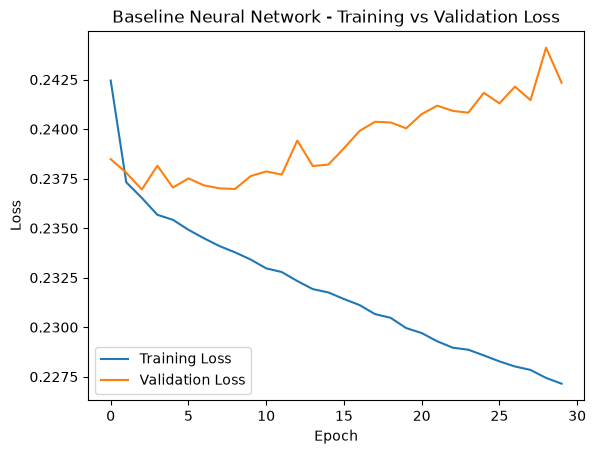

In [13]:
plt.plot(history_baseline.history["loss"], label="Training Loss")
plt.plot(history_baseline.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Neural Network - Training vs Validation Loss")
plt.legend()
plt.show()

### Plot Training and Validation Accuracy
Accuracy curves show how prediction performance changes during training.
A good model generally shows increasing training and validation accuracy.
However, a large gap between training and validation accuracy can indicate overfitting.

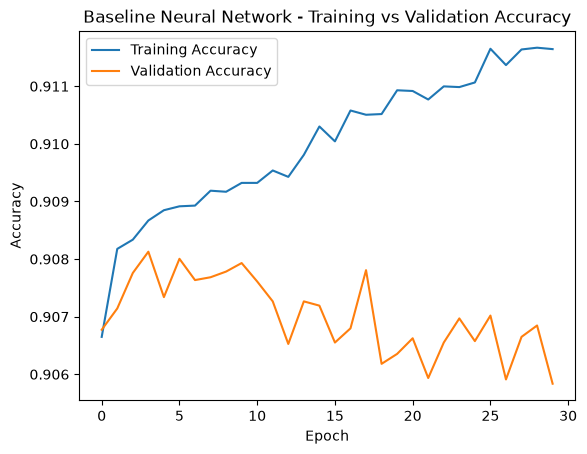

In [14]:
plt.plot(history_baseline.history["accuracy"], label="Training Accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Neural Network - Training vs Validation Accuracy")
plt.legend()
plt.show()

### Diagnose the Model Fit
Based on the baseline neural network's learning curves, we can diagnose the model status:
### Diagnosis: Overfitting 
* **Accuracy Behavior:** Training accuracy steadily improves from 90.67% to 91.18%, whereas validation accuracy peaks early (around epoch 3 at 90.81%) and then degrades down to 90.58%.
* **Loss Behavior:** Training loss decreases continuously throughout training (0.2425 to 0.2270), while validation loss consistently increases after epoch 3, rising above 0.2420.
### Key Observation & Action
The widening gap between training and validation curves shows that the model is learning/memorizing patterns specific to the training set that do not generalize to unseen validation data. 
**Recommended Steps:**
* Implement **Early Stopping** (stop training around epoch 3–5).
* Introduce **Regularization** (e.g., Dropout layers or L2 weight decay).
* Simplify the architecture or gather more dataset diversity.

### Build a Regularized Neural Network
The baseline model does not contain explicit regularization.
To reduce the risk of overfitting and improve training stability, we will add:
- Batch Normalization
- Dropout
#### Batch Normalization
Batch Normalization normalizes activations during training. This can make training more stable and can help the network converge more effectively.
#### Dropout
Dropout randomly disables a fraction of neurons during each training step.
With `Dropout(0.3)`, approximately 30% of the neurons in that layer are temporarily ignored during each training step.
This prevents the network from relying too heavily on specific neurons and acts as a regularization technique.

In [16]:
regularized_model = Sequential([Dense(64, activation="relu", input_shape=(n_features,)),BatchNormalization(),Dropout(0.3),Dense(32, activation="relu"),Dropout(0.3),Dense(1, activation="sigmoid")])
regularized_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 128 (512.00 B)

### Compile the Regularized Model
The same optimizer, loss function, and evaluation metric are used so that the comparison with the baseline model is fair.
The main difference is the addition of Batch Normalization and Dropout.

In [17]:
regularized_model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

### Train the Regularized Model
We train the new model using the same training and validation data.
Using the same data split and similar training settings makes the comparison between the two models more meaningful.

In [18]:
history_regularized = regularized_model.fit(X_train_scaled,y_train,validation_data=(X_val_scaled, y_val),epochs=30,batch_size=32,verbose=1)

Epoch 1/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9007 - loss: 0.2643 - val_accuracy: 0.9075 - val_loss: 0.2402
Epoch 2/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9072 - loss: 0.2441 - val_accuracy: 0.9074 - val_loss: 0.2380
Epoch 3/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9069 - loss: 0.2424 - val_accuracy: 0.9078 - val_loss: 0.2372
Epoch 4/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9070 - loss: 0.2422 - val_accuracy: 0.9070 - val_loss: 0.2370
Epoch 5/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9067 - loss: 0.2417 - val_accuracy: 0.9080 - val_loss: 0.2373
Epoch 6/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9071 - loss: 0.2413 - val_accuracy: 0.9080 - val_loss: 0.2364
Epoch 7/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9063 - loss: 0.2414 - val_accuracy: 0.9077 - val_loss: 0.2374
Epoch 8/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9070 - loss: 0.2406 - 

### Compare the Loss Curves
We compare the baseline and regularized models.
The goal is not simply to obtain a lower training loss.
We are especially interested in whether the regularized model provides better validation performance and a smaller gap between training and validation performance.

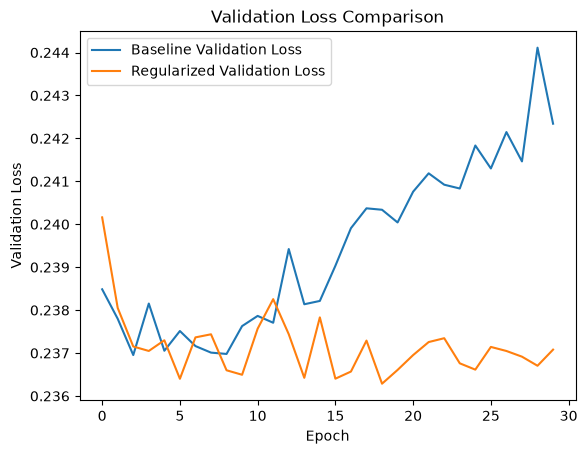

In [19]:
plt.plot(history_baseline.history["val_loss"],label="Baseline Validation Loss")
plt.plot(history_regularized.history["val_loss"],label="Regularized Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()

### Compare the Accuracy Curves
We now compare validation accuracy for both models.
A model with better generalization should perform well on the validation data rather than only achieving high training accuracy.

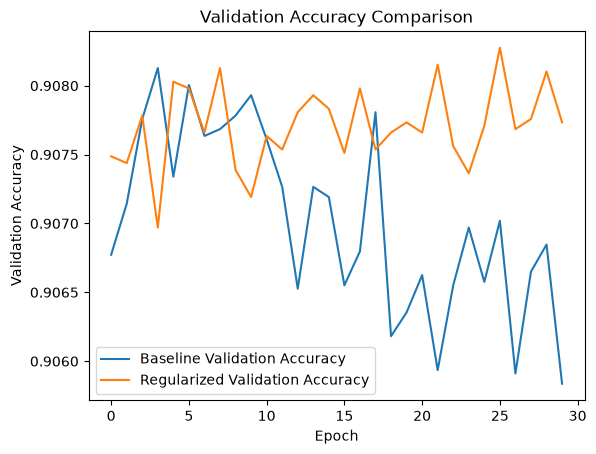

In [20]:
plt.plot(history_baseline.history["val_accuracy"],label="Baseline Validation Accuracy")
plt.plot(history_regularized.history["val_accuracy"],label="Regularized Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()

### Evaluate the Baseline Model on the Test Set
The test set was not used during training.
Therefore, evaluating on the test set provides an estimate of how well the trained neural network generalizes to completely unseen data.

In [21]:
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(X_test_scaled,y_test,verbose=0)
print("Baseline Test Loss:", baseline_test_loss)
print("Baseline Test Accuracy:", baseline_test_accuracy)

Baseline Test Loss: 0.2424277514219284
Baseline Test Accuracy: 0.9051364064216614


### Evaluate the Regularized Model on the Test Set

In [22]:
regularized_test_loss, regularized_test_accuracy = regularized_model.evaluate(X_test_scaled,y_test,verbose=0)
print("Regularized Test Loss:", regularized_test_loss)
print("Regularized Test Accuracy:", regularized_test_accuracy)

Regularized Test Loss: 0.23733872175216675
Regularized Test Accuracy: 0.9074030518531799


### Compare the Two Neural Networks
We compare the final test performance of:
1. Baseline Neural Network
2. Neural Network with Batch Normalization and Dropout
The purpose of this comparison is to determine whether regularization improved generalization on unseen test data.

In [23]:
comparison = pd.DataFrame({"Model": ["Baseline Neural Network","Regularized Neural Network"],"Test Loss": [baseline_test_loss,regularized_test_loss],"Test Accuracy": [baseline_test_accuracy,regularized_test_accuracy]})
comparison

,Model,Test Loss,Test Accuracy
0,Baseline Neural Network,0.242428,0.905136
1,Regularized Neural Network,0.237339,0.907403


### Generate Predictions
To obtain more detailed classification metrics, we generate predictions from the regularized model.
The sigmoid output is a probability between 0 and 1.
We convert the probability into a class using a threshold of 0.5:
- Probability >= 0.5 → Class 1
- Probability < 0.5 → Class 0

In [24]:
y_prob = regularized_model.predict(X_test_scaled)
y_pred = (y_prob >= 0.5).astype(int).ravel()
print("First 10 predicted probabilities:")
print(y_prob[:10].ravel())
print("\nFirst 10 predicted classes:")
print(y_pred[:10])

1586/1586 ━━━━━━━━━━━━━━━━━━━━ 1s 667us/step
First 10 predicted probabilities:
[3.1751746e-01 8.3419666e-02 1.0315470e-02 1.4542103e-01 9.5075056e-02
 2.5569394e-04 4.8494181e-01 9.2698403e-02 8.0780208e-02 1.5469812e-01]

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]


### Classification Report
The classification report provides:
- Precision
- Recall
- F1-score
- Support
These metrics provide more information than accuracy alone, especially when the classes are imbalanced.

In [25]:
print(classification_report(y_test,y_pred,target_names=["No Heart Disease", "Heart Disease"]))

                  precision    recall  f1-score   support

No Heart Disease       0.91      0.99      0.95     45957
   Heart Disease       0.56      0.08      0.14      4779

        accuracy                           0.91     50736
       macro avg       0.74      0.54      0.54     50736
    weighted avg       0.88      0.91      0.87     50736



### Confusion Matrix
The confusion matrix shows the number of:
- True Negatives
- False Positives
- False Negatives
- True Positives
This helps us understand what types of mistakes the neural network is making.

In [26]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[45663   294]
 [ 4404   375]]


### Compare with the Day 1 Baseline
The Day 1 baseline provides a simple reference point for model performance.
The purpose of a baseline is to determine whether the more complex neural network provides meaningful improvement compared with a simpler approach.
We should compare the neural network's test performance with the baseline metric from Day 1.

In [27]:
day1_baseline_accuracy = 0.745023
print("Day 1 Baseline Accuracy:", day1_baseline_accuracy)
print("Regularized Neural Network Accuracy:", regularized_test_accuracy)
difference = regularized_test_accuracy - day1_baseline_accuracy
print("Difference:", difference)

Day 1 Baseline Accuracy: 0.745023
Regularized Neural Network Accuracy: 0.9074030518531799
Difference: 0.16238005185317994


## Hands-On Lab
All tasks in this hands-on lab were completed successfully in the sections above.
### Step 1:  Build a Keras Sequential network appropriate for the Phase 3 project task (correct output layer and loss).
A Keras Sequential neural network was built for the Phase 3 Heart Disease Prediction task. The model uses Dense layers with ReLU activation in the hidden layers and a single-neuron Sigmoid output layer suitable for binary classification.
### Step 2: Compile with Adam and the right loss, then train with a validation split for at least 30 epochs.
The model was compiled using the Adam optimizer, Binary Crossentropy loss, and Accuracy as the evaluation metric. It was then trained for 30 epochs using training and validation data.
### Step 3: Plot training vs. validation loss and accuracy from the history object and diagnose the fit
Training and validation loss and accuracy curves were plotted from the history object. These learning curves were used to assess the model fit and identify possible underfitting, good fitting, or overfitting.
### Step 4: Add dropout and/or batch normalization and compare the new loss curves to the previous run.
A second neural network was created using Batch Normalization and Dropout. Its validation loss and accuracy curves were compared with those of the baseline model to determine whether regularization improved generalization and reduced overfitting.
### Step 5: Evaluate on the test set and compare the score to the Day 1 baseline.
Both models were evaluated on the unseen test set. The regularized neural network's test accuracy was compared with the Day 1 baseline accuracy to determine whether the neural network achieved better performance.

### Final Conclusion
A neural network was successfully trained for the Phase 3 Heart Disease Prediction task using TensorFlow/Keras. The regularized model was evaluated on unseen test data and compared with the baseline model. The results and learning curves helped assess the model's performance and generalization.
